# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística
from scipy import stats

# Pruebas estadísticas específicas
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
df.head () # mostrar las primeras 5 filas


,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
df.info() # información general


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: 

El dataset contiene 40.000 registros distribuidos en 9 columnas y no presenta valores nulos, por lo que todas las filas cuentan con información completa. No obstante, se realizarán algunos ajustes en los tipos de datos para mejorar la eficiencia y facilitar el análisis. 

La columna *date*, actualmente de tipo object, se convertirá a formato datetime, ya que representa fechas y este formato permitirá realizar análisis temporales de manera adecuada. 

Las columnas *landing, region, dispositivo, traffic_source y user_type* se convertirán a tipo category, debido a que contienen variables categóricas que representan grupos o clasificaciones, y no valores numéricos sobre los que tenga sentido realizar operaciones matemáticas. 

La columna *converted*, se mantendrá como int64, ya que contiene una variable binaria con valores 0 y 1. Aunque podría representarse como bool, mantenerla como variable numérica facilitará el cálculo de tasas de conversión mediante promedios y su utilización posterior en pruebas estadísticas y tablas de contingencia.

Por su parte, *user_id* se mantendrá como object, ya que funciona como identificador único y no requiere cálculos numéricos, mientras que *gasto* conservará el tipo float64, dado que representa el monto monetario gastado por cada usuario y puede incluir valores decimales.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()
df['date'] = pd.to_datetime(df['date'])
df['date'].min(), df['date'].max()

(Timestamp('2026-01-01 00:00:00'), Timestamp('2026-01-28 00:00:00'))

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1]['gasto'].describe().round(2)

count    5706.00
mean       65.37
std        30.90
min        12.12
25%        42.95
50%        59.86
75%        80.37
max       303.68
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen

print("\nConteo de categorías:")
for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(f"\n{col}:")
    print(df[col].value_counts()) #completa el código)


Conteo de categorías:

landing:
B    20018
A    19982
Name: landing, dtype: int64

region:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

dispositivo:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

traffic_source:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

user_type:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


✍️ **Comentario**: 

No se observan valores negativos ni categorías mal escritas en las variables analizadas.

 -*user_id*: contiene 40.000 identificadores únicos.

-*date*: presenta fechas dentro del periodo esperado, del 1 al 28 de enero de 2026.

-*landing*: contiene únicamente las categorías esperadas: A y B, con una distribución equilibrada.

-*region, dispositivo, traffic_source y user_type*: contienen categorías válidas y no presentan valores inesperados.

-*converted*: contiene los valores esperados: 0 y 1.

-*gasto*: no se observan valores negativos. Los valores 0 son esperados porque corresponden a usuarios que no realizaron una conversión.

En general, las columnas presentan valores esperados y no se requieren correcciones adicionales en los valores registrados.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [11]:

# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto'] #completa el código
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto'] #completa el código

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)
print('Resumen gasto A:')
print(gasto_A.describe().round(2))

print('\nResumen gasto B:')
print(gasto_B.describe().round(2))


Resumen gasto A:
count    2512.00
mean       61.09
std        28.88
min        12.12
25%        40.61
50%        55.84
75%        74.84
max       303.68
Name: gasto, dtype: float64

Resumen gasto B:
count    3194.00
mean       68.75
std        32.00
min        12.98
25%        45.21
50%        62.57
75%        84.28
max       249.99
Name: gasto, dtype: float64


### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de los usuarios que convirtieron es igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** El gasto promedio de los usuarios que convirtieron es diferente entre la página A y la página B.

In [12]:
# Aplicar prueba
from scipy.stats import ttest_ind

resultado = ttest_ind(gasto_A, gasto_B, equal_var=False)

print('Estadístico t:', resultado.statistic)
print('Valor p:', resultado.pvalue)
# Visualizar resultados


Estadístico t: -9.48101092267275
Valor p: 3.627602231521493e-21


In [13]:
# Gasto de usuarios convertidos por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']
# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [14]:
alpha = 0.05

if resultado.pvalue < alpha:
    print('Se rechaza la hipótesis nula.')
else:
    print('No se rechaza la hipótesis nula.')

Se rechaza la hipótesis nula.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula, ya que el valor p obtenido es aproximadamente 0,0000000000000000000363, menor que el nivel de significancia establecido (α = 0,05).

**Interpretación de negocio:**  

Existe evidencia estadísticamente significativa de una diferencia en el gasto promedio de los usuarios que convirtieron entre las páginas A y B. La página B presenta un gasto promedio mayor (68,75) que la página A (61,09).

Por lo tanto, en los datos analizados, la página B genera un mayor gasto promedio por usuario convertido. Sin embargo, este resultado no demuestra por sí solo que el cambio en la página sea la causa de que los usuarios gasten más.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en las páginas A y B.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre las páginas A y B.

In [31]:

# Número de usuarios convertidos por página
convertidos_por_pagina = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
total_por_pagina = df['landing'].value_counts()

print("Usuarios convertidos por página:\n", convertidos_por_pagina)
print("\nTotal de usuarios por página:\n", total_por_pagina)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 B    20018
A    19982
Name: landing, dtype: int64


In [32]:
# Aplicar prueba
convertidos = [
    convertidos_por_pagina['A'],
    convertidos_por_pagina['B']]

# Total de usuarios
totales = [
    total_por_pagina['A'],
    total_por_pagina['B']]

# Prueba z de proporciones
z_stat, p_value = proportions_ztest(
    count=convertidos,
    nobs=totales)

print("Estadístico Z:", z_stat)
print("Valor p:", p_value)

Estadístico Z: -9.677362674655983
Valor p: 3.7629765627523803e-22


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación entre la fuente de tráfico y la conversión.
- **Hipótesis alternativa (H₁):** Existe asociación entre la fuente de tráfico y la conversión.

In [33]:

tabla_trafico_conversion = pd.crosstab(
    df['traffic_source'],
    df['converted']
)

print("Tabla de contingencia:")
print(tabla_trafico_conversion)


Tabla de contingencia:
converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [18]:
# Aplicar prueba
from scipy.stats import chi2_contingency

chi2, p_value, grados_libertad, frecuencias_esperadas = chi2_contingency(
    tabla_trafico_conversion
)

print("Estadístico Chi-cuadrado:", chi2)
print("Valor p:", p_value)


Estadístico Chi-cuadrado: 8.662108841397938
Valor p: 0.0341375947833914


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula, ya que el valor p obtenido (0,0341) es menor que el nivel de significancia de 0,05.

**Interpretación de negocio:**  
Existe evidencia estadísticamente significativa de una asociación entre la fuente de tráfico y la conversión. Esto indica que la conversión no se distribuye exactamente de la misma manera entre los diferentes canales de tráfico.

Sin embargo, esta prueba no permite determinar qué canal es responsable de la diferencia ni demuestra que una fuente de tráfico cause una mayor conversión. Para identificar qué canales presentan las tasas de conversión más altas, es necesario revisar las tasas de conversión de cada fuente por separado.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación entre el tipo de usuario y la conversión. La tasa de conversión es independiente de si el usuario es nuevo o recurrente.
- **Hipótesis alternativa (H₁):** Existe una asociación entre el tipo de usuario y la conversión. La tasa de conversión difiere entre usuarios nuevos y recurrentes.

In [34]:

tabla_usuario_conversion = pd.crosstab(
    df['user_type'],
    df['converted'])

print("Tabla de contingencia:")
print(tabla_usuario_conversion)


Tabla de contingencia:
converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [20]:
tasa_conversion_usuario = df.groupby('user_type')['converted'].mean() * 100

print("Tasa de conversión por tipo de usuario:")
print(tasa_conversion_usuario.round(2))

Tasa de conversión por tipo de usuario:
user_type
Nuevo         14.36
Recurrente    14.09
Name: converted, dtype: float64


In [21]:
# Aplicar prueba
from scipy.stats import chi2_contingency

chi2, p_value, grados_libertad, frecuencias_esperadas = chi2_contingency(
    tabla_usuario_conversion
)

print("Estadístico Chi-cuadrado:", chi2)
print("Valor p:", p_value)


Estadístico Chi-cuadrado: 0.5134849494478645
Valor p: 0.4736341272301974


### 📝 Conclusión e interpretación

**Decisión:**  

No existe una asociación estadísticamente significativa entre el tipo de usuario (nuevo o recurrente) y la conversión.

**Interpretación de negocio:**  

La prueba Chi-cuadrado no muestra evidencia estadísticamente significativa de una asociación entre el tipo de usuario y la conversión.
Las tasas de conversión observadas son muy similares: *14,36%* en usuarios nuevos frente a *14,09%* en usuarios recurrentes, una diferencia de apenas *0,27%*.

Por lo tanto, no hay evidencia suficiente para considerar el tipo de usuario como un factor relevante para diferenciar la conversión. No se recomienda crear una campaña exclusiva para usuarios nuevos basándose únicamente en esta diferencia.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

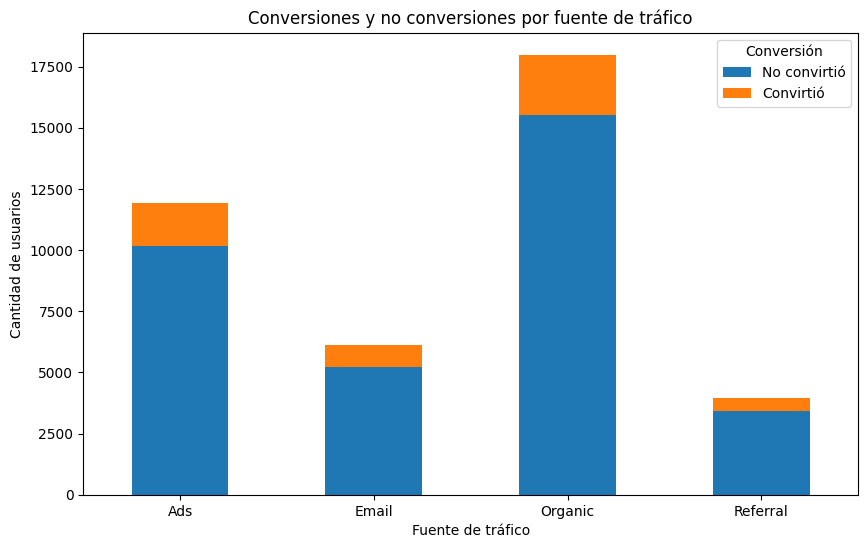

In [22]:
tabla_trafico = pd.crosstab(
    df['traffic_source'],
    df['converted']
)

tabla_trafico.columns = ['No convirtió', 'Convirtió']

tabla_trafico.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Conversiones y no conversiones por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Cantidad de usuarios')
plt.xticks(rotation=0)
plt.legend(title='Conversión')
plt.show()

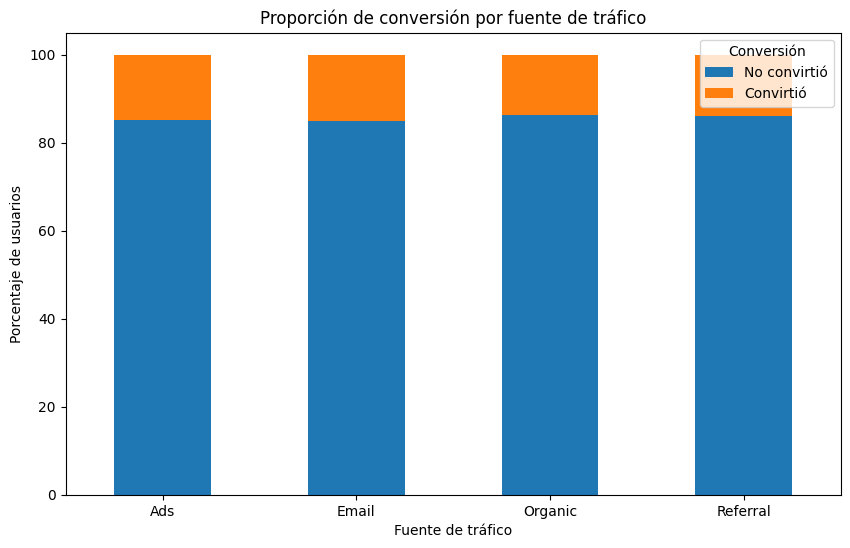

In [23]:
proporcion_trafico = pd.crosstab(
    df['traffic_source'],
    df['converted'],
    normalize='index'
) * 100

proporcion_trafico.columns = ['No convirtió', 'Convirtió']

proporcion_trafico.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Proporción de conversión por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Porcentaje de usuarios')
plt.xticks(rotation=0)
plt.legend(title='Conversión')
plt.show()

✍️ **Comentario**: 

La primera gráfica muestra diferencias importantes en el volumen de usuarios según la fuente de tráfico. En términos absolutos, *Organic* concentra una mayor cantidad de usuarios convertidos, pero este resultado debe interpretarse considerando que también es uno de los canales con mayor volumen de tráfico.

Al analizar la proporción de usuarios que convierten dentro de cada fuente, las diferencias entre los canales son mucho menores. Las tasas de conversión se mantienen en niveles relativamente similares, aproximadamente entre el 14% y el 15%, por lo que no se observa una ventaja marcada de una fuente sobre las demás en términos de efectividad.

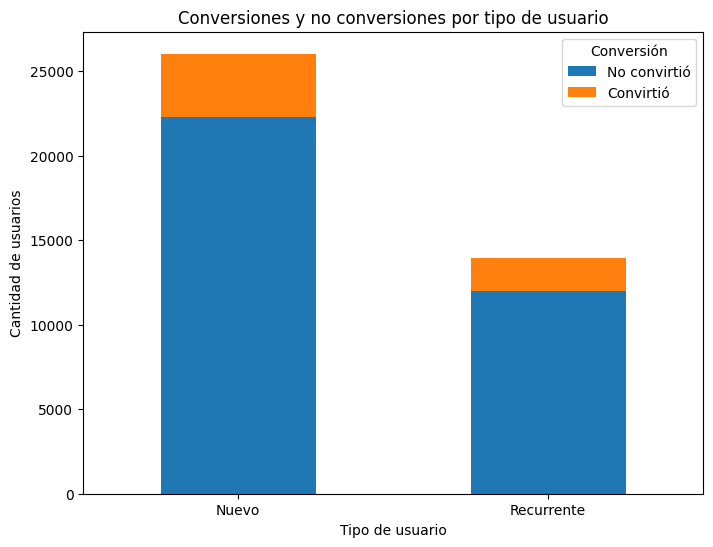

In [24]:
tabla_usuario = pd.crosstab(
    df['user_type'],
    df['converted']
)

tabla_usuario.columns = ['No convirtió', 'Convirtió']

tabla_usuario.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6)
)

plt.title('Conversiones y no conversiones por tipo de usuario')
plt.xlabel('Tipo de usuario')
plt.ylabel('Cantidad de usuarios')
plt.xticks(rotation=0)
plt.legend(title='Conversión')
plt.show()

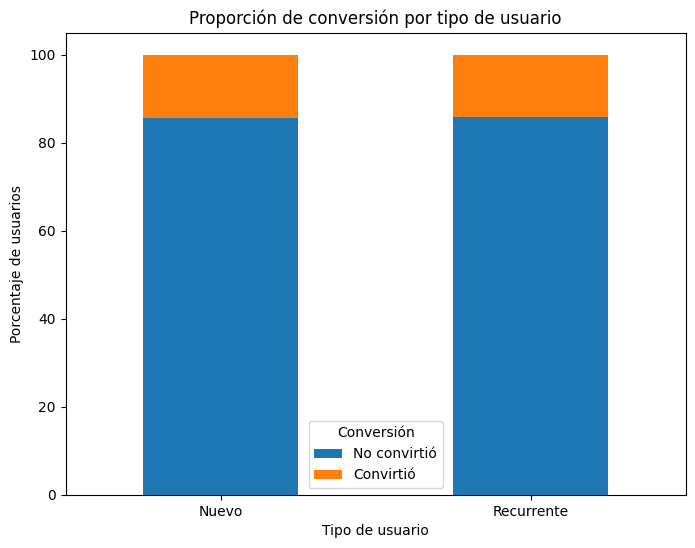

In [25]:
proporcion_usuario = pd.crosstab(
    df['user_type'],
    df['converted'],
    normalize='index'
) * 100

proporcion_usuario.columns = ['No convirtió', 'Convirtió']

proporcion_usuario.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6)
)

plt.title('Proporción de conversión por tipo de usuario')
plt.xlabel('Tipo de usuario')
plt.ylabel('Porcentaje de usuarios')
plt.xticks(rotation=0)
plt.legend(title='Conversión')
plt.show()

✍️ **Comentario**: 

La primera gráfica muestra una mayor concentración de usuarios nuevos en comparación con los usuarios recurrentes. Por esta razón, también se observa un mayor número absoluto de conversiones entre los usuarios nuevos.
Sin embargo, al analizar los datos en términos porcentuales, la diferencia entre ambos grupos es muy reducida.

El volumen de usuarios entre ambos segmentos y su nivel de conversión es muy similar.
Por lo tanto, el tipo de usuario, por sí solo, no parece ser un criterio determinante para diferenciar el comportamiento de conversión en este experimento. Se recomienda enfocar el análisis y las decisiones comerciales en variables que presenten diferencias más relevantes en conversión.

### Relación entre el tipo de usuario y la conversión

In [26]:
resumen_trafico = (
    df.groupby('traffic_source')['converted']
      .agg(
          usuarios='count',
          conversiones='sum',
          tasa_conversion='mean'
      )
)

resumen_trafico['tasa_conversion'] *= 100

resumen_trafico = resumen_trafico.sort_values(
    'tasa_conversion',
    ascending=False
)

print(resumen_trafico.round(2))

                usuarios  conversiones  tasa_conversion
traffic_source                                         
Email               6123           918            14.99
Ads                11935          1759            14.74
Referral            3955           549            13.88
Organic            17987          2480            13.79


In [27]:
rendimiento_trafico = (
    df.groupby('traffic_source')
      .agg(
          usuarios=('user_id', 'count'),
          conversiones=('converted', 'sum'),
          valor_generado=('gasto', 'sum')
      )
)

# Calcular indicadores adicionales
rendimiento_trafico['tasa_conversion'] = (
    rendimiento_trafico['conversiones'] /
    rendimiento_trafico['usuarios'] * 100
)

rendimiento_trafico['valor_promedio_usuario'] = (
    rendimiento_trafico['valor_generado'] /
    rendimiento_trafico['usuarios']
)

rendimiento_trafico['valor_promedio_conversion'] = (
    rendimiento_trafico['valor_generado'] /
    rendimiento_trafico['conversiones']
)

# Mostrar resultados ordenados
rendimiento_trafico = rendimiento_trafico.sort_values(
    'tasa_conversion',
    ascending=False
).round(2)

rendimiento_trafico

,usuarios,conversiones,valor_generado,tasa_conversion,valor_promedio_usuario,valor_promedio_conversion
traffic_source,,,,,,
Email,6123,918,58715.05,14.99,9.59,63.96
Ads,11935,1759,115886.51,14.74,9.71,65.88
Referral,3955,549,36185.50,13.88,9.15,65.91
Organic,17987,2480,162235.09,13.79,9.02,65.42


✍️ **Comentario**: 

Al analizar conjuntamente el número de usuarios, las conversiones y la tasa de conversión, se observa que Organic y Ads concentran el mayor volumen de usuarios, por lo que también generan una cantidad importante de conversiones. Sin embargo, cuando se analiza el porcentaje de usuarios que convierte dentro de cada fuente, el resultado es diferente.

Email presenta la tasa de conversión más alta *14,99%*, seguido de Ads *14,74%*, Referral *13,88%* y Organic *13,79%*. Esto significa que, proporcionalmente, Email convierte ligeramente mejor que las demás fuentes. No obstante, la diferencia entre Email y Organic es de aproximadamente *1,20%* , por lo que no debería interpretarse automáticamente como una ventaja grande o suficiente para afirmar que Email es el canal más eficiente en términos generales.

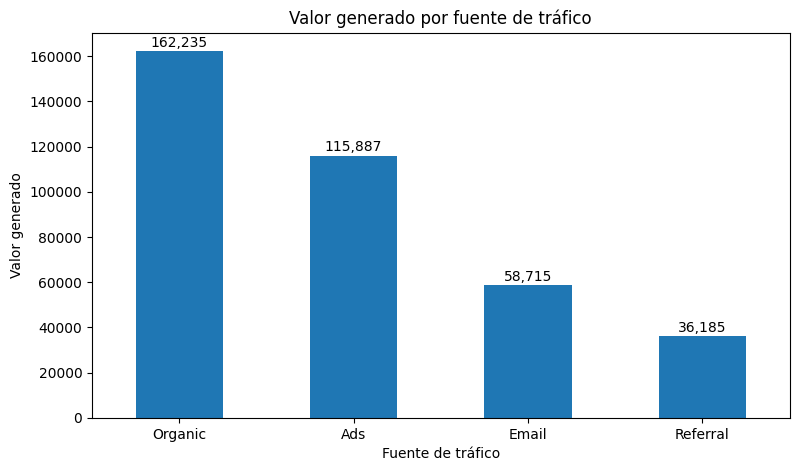

In [28]:
valor_generado = (
    df.groupby('traffic_source')['gasto']
      .sum()
).sort_values(ascending=False)

ax = valor_generado.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Valor generado por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Valor generado')
plt.xticks(rotation=0)

for i, valor in enumerate(valor_generado):
    ax.text(
        i,
        valor + 2000,
        f'{valor:,.0f}',
        ha='center'
    )

plt.show()

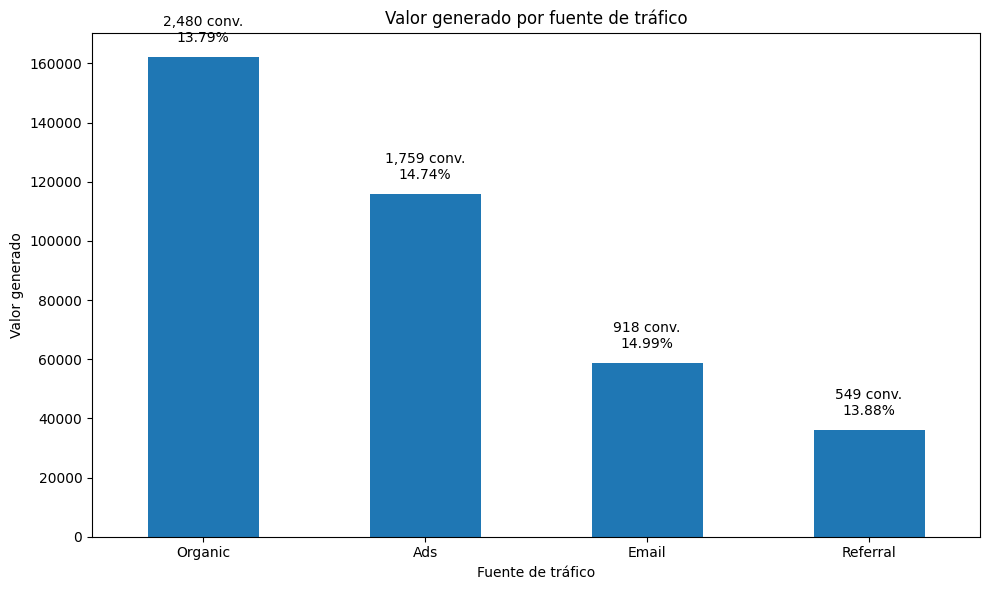

,usuarios,conversiones,tasa_conversion,valor_generado
traffic_source,,,,
Organic,17987,2480,13.79,162235.09
Ads,11935,1759,14.74,115886.51
Email,6123,918,14.99,58715.05
Referral,3955,549,13.88,36185.50


In [29]:
rendimiento_trafico = df.groupby('traffic_source').agg(
    usuarios=('user_id', 'count'),
    conversiones=('converted', 'sum'),
    valor_generado=('gasto', 'sum')
)

rendimiento_trafico['tasa_conversion'] = (
    rendimiento_trafico['conversiones'] / rendimiento_trafico['usuarios'] * 100
)

rendimiento_trafico = rendimiento_trafico.sort_values(
    'valor_generado', ascending=False
)

# Gráfico
ax = rendimiento_trafico['valor_generado'].plot(
    kind='bar', figsize=(10, 6)
)

plt.title('Valor generado por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Valor generado')
plt.xticks(rotation=0)

for i in range(len(rendimiento_trafico)):
    ax.text(
        i,
        rendimiento_trafico['valor_generado'].iloc[i] + 5000,
        f"{rendimiento_trafico['conversiones'].iloc[i]:,} conv.\n"
        f"{rendimiento_trafico['tasa_conversion'].iloc[i]:.2f}%",
        ha='center'
    )

plt.tight_layout()
plt.show()

# Tabla final
rendimiento_trafico[
    ['usuarios', 'conversiones', 'tasa_conversion', 'valor_generado']
].round(2)

✍️ **Comentario**: 

Al analizar también el volumen y el valor generado, se observa una situación diferente. Ads registra 11.935 usuarios y genera un valor de 115.886, mientras que Email alcanza 6.123 usuarios y genera 58.715. Por su parte, Organic concentra el mayor volumen de usuarios (17.987) y conversiones (2.480), lo que se refleja en el mayor valor generado, con 162.235.

Por lo tanto, la tasa de conversión por sí sola no permite determinar cuál es el canal con mejor desempeño. Email destaca por su tasa de conversión, mientras que Ads y Organic presentan una mayor escala y generación de valor.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?

El experimento A/B muestra un mejor desempeño de la página B frente a la página A tanto en conversión como en valor promedio generado por los usuarios que convierten. La página B alcanzó una tasa de conversión de 15,95%, frente al 12,57% de la página A, una diferencia de 3,38 puntos porcentuales. Esta diferencia fue estadísticamente significativa según la prueba de proporciones.

Además, entre los usuarios que realizaron una conversión, la página B presentó un valor promedio de *68,75*, frente a *61,09* en la página A. La diferencia de *7,66%* también resultó estadísticamente significativa lo que indica que es poco probable que la diferencia observada se explique únicamente por el azar. 
Los $7,66 adicionales por conversión podrían representar un impacto relevante al acumularse en un volumen elevado de conversiones, pero su importancia para el negocio debe evaluarse considerando el volumen de usuarios, el margen y los costos asociados.

En conjunto, estos resultados posicionan a la página B como la alternativa con mejores resultados observados en el experimento, aunque la significancia estadística por sí sola no permite atribuir causalidad si el diseño experimental no garantiza una asignación adecuada de los usuarios.

La principal oportunidad identificada es optimizar la experiencia de la página mediante la alternativa B y gestionar los canales de tráfico considerando tanto la tasa de conversión como el volumen y el valor generado. 

Se recomienda mantener y optimizar el desempeño de Organic y Ads, buscando mejorar su tasa de conversión sin perder el volumen que actualmente aporta valor al negocio. Al mismo tiempo, se recomienda evaluar una mayor inversión en Email, aprovechando su mayor tasa de conversión observada y realizando pruebas que permitan determinar si ampliar este canal genera un crecimiento rentable.

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La página B registró un gasto promedio de *68,75* por conversión, mientras que la página A alcanzó *61,09*.
- La diferencia fue de $7,66 por conversión y resultó estadísticamente significativa (p < 0,001).
- **Interpretación:**

La página B presenta un mayor gasto promedio observado y la diferencia difícilmente se explica únicamente por el azar. Sin embargo, la significancia estadística no implica necesariamente que los *7,66* tengan una importancia económica suficiente para justificar por sí solos un cambio amplio de estrategia; su impacto debe evaluarse considerando el volumen de conversiones y los costos asociados.
<br>

**Tasa de conversión:** 
- La página B alcanzó una tasa de conversión de 15,95%, frente al 12,57% de la página A
- La diferencia fue de 3,38 puntos porcentuales y resultó estadísticamente significativa (p < 0,001).
- **Interpretación:**

La página B presenta un mejor desempeño observado en conversión que la página A. Los resultados respaldan continuar evaluando la página B como alternativa, aunque antes de establecerla definitivamente como la mejor opción conviene considerar también la relevancia económica de la mejora y validar que el resultado se mantenga en futuras pruebas.

#### 📊 **Segmentación por fuente de tráfico**
- Observacion aquí: Email presenta la mayor tasa de conversión observada (14,99%), seguido de Ads (14,74%), mientras que Organic registra la menor (13,79%). Sin embargo, Organic concentra el mayor volumen de conversiones, con 2.480, debido a que también es la fuente con mayor cantidad de usuarios.

- **Interpretación:**

La fuente de tráfico muestra diferencias en las tasas de conversión, aunque estas diferencias son relativamente pequeñas. Email destaca por su tasa de conversión, mientras que Organic y Ads aportan un mayor volumen de conversiones y valor generado. Por ello, el desempeño de cada canal debe evaluarse considerando tanto la tasa de conversión como su volumen y valor económico.

#### 📊 **Segmentación por tipo de usuario**
- Observacion aquí: Los usuarios Nuevos presentan una tasa de conversión de 14,36%, mientras que los Recurrentes alcanzan 14,09%, una diferencia de apenas 0,27 puntos porcentuales.

- **Interpretación:**

No se observa una diferencia relevante en la tasa de conversión entre usuarios Nuevos y Recurrentes. Además, la prueba estadística no encontró evidencia suficiente de una asociación entre el tipo de usuario y la conversión (p = 0,474). Por lo tanto, el tipo de usuario no parece ser un factor diferenciador importante para la conversión en este conjunto de datos.
Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

#### 💡 **Recomendaciones de negocio:** 
- 1. **Priorizar la página B en futuras campañas y pruebas**:
Se recomienda continuar utilizando la página B como principal alternativa de prueba, con el fin de aprovechar su mayor tasa de conversión observada y su mayor gasto promedio por usuario que convirtió. Antes de realizar un cambio definitivo, conviene validar que estos resultados se mantengan en nuevas pruebas y evaluar si la mejora representa un impacto económico relevante para el negocio.

- 2. **Optimizar las fuentes de tráfico según su desempeño**:
Se recomienda mantener y optimizar Organic y Ads, debido al volumen de usuarios, conversiones y valor generado que aportan, mientras se realizan pruebas específicas con Email para evaluar si su mayor tasa de conversión puede traducirse en un crecimiento rentable. Para tomar decisiones de inversión, sería necesario incorporar los costos de cada canal y comparar su rentabilidad.